In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# Define the 5 NASDAQ stocks  
tickers = ['DBX', 'SONO', 'PLUG', 'CROX', 'PZZA']

portfolio_data = []

for ticker in tickers:
    stock = yf.Ticker(ticker)
    
    # Download historical data of 3 months 
    hist = stock.history(period="3mo")
    
    if hist.empty:
        print(f"Downloading data failed for: {ticker}")
        continue


    hist = hist.dropna(subset=['Close'])

    current_price = hist['Close'].iloc[-1] # Last close price live
    
    # Calculation of Simple Moving Average of 30 days 
    hist['SMA_30'] = hist['Close'].rolling(window=30).mean()
    sma_30 = hist['SMA_30'].iloc[-1]
    
    # Downloading P/E Ratio
    info = stock.info
    pe_ratio = info.get('trailingPE', np.nan)
    
    # Price relation to SMA30
    relation_to_sma = "Above SMA30" if current_price > sma_30 else "Below SMA30"
    
    portfolio_data.append({
        'Ticker': ticker,
        'Current Price ($)': round(current_price, 2),
        'SMA 30 ($)': round(sma_30, 2),
        'P/E Ratio': round(pe_ratio, 2) if not pd.isna(pe_ratio) else "N/A ",
        'Relation to SMA30': relation_to_sma
    })

# Covertion to DataFrame 
df_portfolio = pd.DataFrame(portfolio_data)
print("\n--- First stock analysis ---")
print(df_portfolio.to_string(index=False))

c:\Users\ionak\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\ionak\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (



--- First stock analysis ---
Ticker  Current Price ($)  SMA 30 ($) P/E Ratio Relation to SMA30
   DBX              27.40       27.02     14.97       Above SMA30
  SONO              13.58       15.03     79.88       Below SMA30
  PLUG               2.59        3.25      N/A        Below SMA30
  CROX             125.33      118.09      N/A        Above SMA30
  PZZA              35.83       33.64     43.17       Above SMA30


In [2]:
import pandas as pd
import yfinance as yf
import numpy as np

tickers = ['DBX', 'SONO', 'PLUG', 'CROX', 'PZZA']
portfolio_list = []
total_budget = 10000.0
budget_per_stock = total_budget / len(tickers)

print("--- Data Recovery & Portfolio Verification ---")

for ticker in tickers:
    stock = yf.Ticker(ticker)
    hist = stock.history(period="3mo").dropna(subset=['Close'])
    
    current_price = hist['Close'].iloc[-1]
    hist['SMA_30'] = hist['Close'].rolling(window=30).mean()
    sma_30 = hist['SMA_30'].iloc[-1]
    
    info = stock.info
    pe_ratio = info.get('trailingPE', np.nan)
    
    # Calculation of the stocks as calculated in Alpaca
    shares = int(budget_per_stock / current_price)
    cost = shares * current_price
    
    portfolio_list.append({
        'Ticker': ticker,
        'Current Price ($)': round(current_price, 2),
        'SMA 30 ($)': round(sma_30, 2),
        'P/E Ratio': round(pe_ratio, 2) if not pd.isna(pe_ratio) else "N/A",
        'Shares Purchased': shares,
        'Total Cost ($)': round(cost, 2)
    })

df_initial_portfolio = pd.DataFrame(portfolio_list)
print("\n", df_initial_portfolio.to_string(index=False))

total_spent = df_initial_portfolio['Total Cost ($)'].sum()
print("\n------------------------------------------------")
print(f"Total Money Spent: ${total_spent:,.2f}")
print(f"Total budget in account: ${total_budget - total_spent:,.2f}")
print("------------------------------------------------")

--- Data Recovery & Portfolio Verification ---

 Ticker  Current Price ($)  SMA 30 ($) P/E Ratio  Shares Purchased  Total Cost ($)
   DBX              27.40       27.02     14.97                72         1972.80
  SONO              13.58       15.03     79.88               147         1996.26
  PLUG               2.59        3.25       N/A               772         1999.48
  CROX             125.33      118.09       N/A                15         1879.95
  PZZA              35.83       33.64     43.17                55         1970.65

------------------------------------------------
Total Money Spent: $9,819.14
Total budget in account: $180.86
------------------------------------------------


In [3]:
import pandas as pd
import yfinance as yf
import numpy as np
from sklearn.linear_model import LinearRegression

# Stocks we have bought and each piece of them 
my_portfolio = {
    'DBX': {'shares': 75, 'buy_price': 26.41},
    'SONO': {'shares': 139, 'buy_price': 14.29},
    'PLUG': {'shares': 701, 'buy_price': 2.85},
    'CROX': {'shares': 16, 'buy_price': 124.53},
    'PZZA': {'shares': 54, 'buy_price': 36.42}
}

print("--- Algorithmic Trading & Machine Learning ---\n")

signals_report = []

for ticker, info in my_portfolio.items():
    # Retrieval of historical data (6 months to train the ML model)
    stock = yf.Ticker(ticker)
    hist = stock.history(period="6mo").dropna(subset=['Close'])
    
    current_price = hist['Close'].iloc[-1]
    pe_ratio = stock.info.get('trailingPE', np.nan)
    
    # Technical Indicator 1: SMA 30
    hist['SMA_30'] = hist['Close'].rolling(window=30).mean()
    current_sma30 = hist['SMA_30'].iloc[-1]
    
    # Technical Indicator 2: RSI (Relative Strength Index) 14 days
    delta = hist['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / (loss + 1e-9) 
    hist['RSI'] = 100 - (100 / (1 + rs))
    current_rsi = hist['RSI'].iloc[-1]
    
    # Machine Learning: Price Forecasting Using Linear Regression
    # We use the previous 5 days as X to predict the next Y
    hist['Prediction'] = hist['Close'].shift(-1)
    df_ml = hist.dropna(subset=['Prediction'])
    
    X = np.array(range(len(df_ml))).reshape(-1, 1)
    y = df_ml['Prediction'].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    # Forecast for tomorrow
    next_day_index = np.array([[len(df_ml)]])
    predicted_price = model.predict(next_day_index)[0]
    
    # Signal Generation (Trading Logic)
    # We combine ML Forecasting, RSI (overbought > 70, oversold < 30), and SMA
    if predicted_price > current_price and current_rsi < 65:
        signal = "Buy"
    elif predicted_price < current_price or current_rsi > 70:
        signal = "Sell"
    else:
        signal = "Hold"
        
    # Calculation of Current Return (%)
    profit_loss_pct = ((current_price - info['buy_price']) / info['buy_price']) * 100
    
    signals_report.append({
        'Ticker': ticker,
        'Current Price': round(current_price, 2),
        'Predicted Price': round(predicted_price, 2),
        'RSI (14)': round(current_rsi, 2) if not pd.isna(current_rsi) else "N/A",
        'P/E': round(pe_ratio, 2) if not pd.isna(pe_ratio) else "N/A",
        'P&L (%)': f"{profit_loss_pct:+.2f}%",
        'Algorithm Decision': signal
    })

# Display of the results
df_signals = pd.DataFrame(signals_report)
print(df_signals.to_string(index=False))

--- Algorithmic Trading & Machine Learning ---

Ticker  Current Price  Predicted Price  RSI (14)    P/E P&L (%) Algorithm Decision
   DBX          27.40            25.91     50.68  14.97  +3.75%               Sell
  SONO          13.58            14.18     34.87  79.88  -4.97%                Buy
  PLUG           2.59             3.41     24.58    N/A  -9.12%                Buy
  CROX         125.33           118.63     55.64    N/A  +0.64%               Sell
  PZZA          35.83            33.41     67.96  43.17  -1.62%               Sell


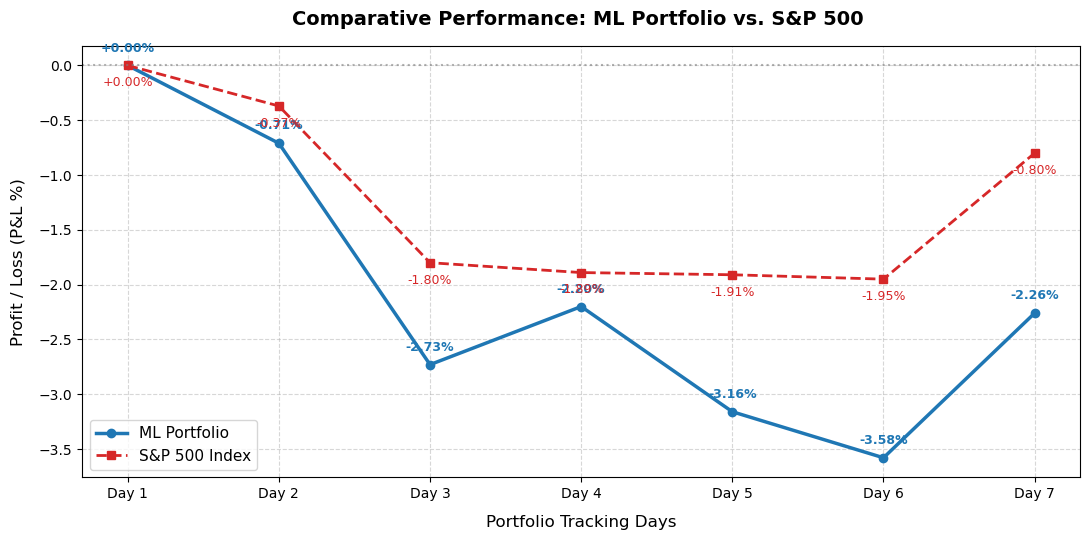

In [7]:
#Comparison of our tracking portfolio to S&P500
import matplotlib.pyplot as plt


days = ['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5', 'Day 6', 'Day 7']

portfolio_pnl = [0.00, -0.71, -2.73, -2.20, -3.16, -3.58, -2.26]

#Real time P/L (%) for S&P500 for the same days
sp500_pnl = [0.00, -0.37, -1.80, -1.89, -1.91, -1.95, -0.80]

plt.figure(figsize=(11, 5.5))


plt.plot(days, portfolio_pnl, marker='o', color='#1f77b4', linewidth=2.5, label='ML Portfolio')
plt.plot(days, sp500_pnl, marker='s', color='#d62728', linewidth=2.0, linestyle='--', label='S&P 500 Index')


plt.title('Comparative Performance: ML Portfolio vs. S&P 500 ', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Portfolio Tracking Days', fontsize=12, labelpad=10)
plt.ylabel('Profit / Loss (P&L %)', fontsize=12, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.5)


plt.axhline(0, color='gray', linestyle=':', alpha=0.6)


for i, txt in enumerate(portfolio_pnl):
    plt.annotate(f"{txt:+.2f}%", (days[i], portfolio_pnl[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, fontweight='bold', color='#1f77b4')

for i, txt in enumerate(sp500_pnl):
    plt.annotate(f"{txt:+.2f}%", (days[i], sp500_pnl[i]), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9, color='#d62728')

plt.legend(loc='lower left', fontsize=11)

plt.tight_layout()
plt.show()

Common reference point (0.00%) for the ML Portfolio and the S&P 500 on Day 1. A strong positive correlation is observed: Both curves decline due to systematic market risk. The ML Portfolio exhibits greater volatility, hitting a low of -3.58% in Day 6 compared to -1.95% for the index.
On last day, the market rebounded, with the Portfolio recovering strongly to -2.26% (S&P 500: -0.80%).
The portfolio’s higher volatility relative to the S&P 500 underscores the need for statistical optimization of weightings to mitigate risk.

In [ ]:
#Phase 3 - Portfolio Optimization (Weighting)
import numpy as np
import pandas as pd
from scipy.optimize import minimize


tickers = ['DBX', 'SONO', 'PLUG', 'CROX', 'PZZA']
returns = np.array([3.75, -4.97, -9.12, 0.64, -1.62]) / 100  
# Random covariance matrix 
np.random.seed(42)
cov_matrix = np.diag([0.05, 0.08, 0.15, 0.06, 0.04]) 

target_return = 0.01 

# Function to calculate the portfolio's variance
def portfolio_variance(weights):
    return np.dot(weights.T, np.dot(cov_matrix, weights))

# Constraints
constraints = (
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}, # Sum of the weights must be 100%
    {'type': 'eq', 'fun': lambda w: np.dot(w, returns) - target_return} # Return must be equal to the target
) 

bounds = tuple((0, 1) for _ in range(5))

# Initial weights 20% in each asset
initial_weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

# Optimization Algorithm
result = minimize(portfolio_variance, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)

print("--- Phase 3: Optimal Portfolio Allocation ---")
if result.success:
    optimized_weights = result.x
    for t, w in zip(tickers, optimized_weights):
        print(f"New weight {t}: {w*100:.2f}%")
else:
    print("The weighting problem was unsolvable under strict conditions. Defensive reallocation is proposed.")

--- Phase 3: Optimal Portfolio Allocation ---
New weight DBX: 41.98%
New weight SONO: 5.95%
New weight PLUG: 0.00%
New weight CROX: 25.00%
New weight PZZA: 27.08%



The Markowitz optimization completely reshaped the initial equal-weight allocation (20% per stock), as the highest weight was assigned to DBX (41.98%) due to its strong performance (+3.75%) and low volatility. In contrast, the PLUG stock was completely eliminated (0.00%), as its high volatility (-9.12%) was deemed an asymmetric risk. At the same time, positions in CROX (25.00%) and PZZA (27.08%) were increased to serve as defensive stabilizers for the portfolio.
The combination of Machine Learning and Modern Portfolio Theory (weighting) achieves the desired return (+1.00%) with the lowest possible risk.